# Module 4: Deep Learning — Brain Tumor Classification
**Course**: Computer Vision | Christian Mata, PhD

**Dataset**: LGG Brain MRI Segmentation (Kaggle — mateuszbuda)

**Task**: Binary classification — does this MRI slice contain a tumor? (yes / no)

**Labels**: Derived from the segmentation masks — if any pixel in the mask is non-zero, the slice contains a tumor.

**Group members**: Martin Çaro, Edison Zyberaj


## 1. Kaggle setup — upload kaggle.json when prompted

In [1]:
!pip install -q kaggle
from google.colab import files
print('Upload your kaggle.json API key:')
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle configured ✓')

Upload your kaggle.json API key:


Saving kaggle.json to kaggle.json
Kaggle configured ✓


## 2. Download and extract the dataset

In [2]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d brain/
print('Download and extraction complete ✓')

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:18<00:00, 40.7MB/s]

Download and extraction complete ✓


## 3. Convert TIF files to PNG and derive classification labels

In [3]:
import os
import glob
import numpy as np
from PIL import Image

# Locate all TIF image files (exclude mask files)
all_tif     = sorted(glob.glob('brain/kaggle_3m/**/*.tif', recursive=True))
image_tifs  = [p for p in all_tif if '_mask' not in p]
mask_tifs   = [p.replace('.tif', '_mask.tif') for p in image_tifs]

print(f'Image TIF files: {len(image_tifs)}')
print(f'Mask  TIF files: {len(mask_tifs)}')
print('Example:', os.path.basename(image_tifs[0]))

Image TIF files: 3929
Mask  TIF files: 3929
Example: TCGA_CS_4941_19960909_1.tif


In [4]:
# Convert TIF → PNG
# Label = 1 (tumor)    if the mask has any non-zero pixel
# Label = 0 (no tumor) if the mask is all zeros

IMG_SIZE = 128

os.makedirs('brain/images', exist_ok=True)
os.makedirs('brain/masks',  exist_ok=True)

image_pngs = []
mask_pngs  = []
labels     = []

for img_tif, msk_tif in zip(image_tifs, mask_tifs):
    img_name = os.path.basename(img_tif).replace('.tif', '.png')
    msk_name = os.path.basename(msk_tif).replace('.tif', '.png')
    img_png  = f'brain/images/{img_name}'
    msk_png  = f'brain/masks/{msk_name}'

    # Images are already 3-channel (pre-contrast, FLAIR, post-contrast)
    Image.open(img_tif).resize((IMG_SIZE, IMG_SIZE)).save(img_png)

    # Masks: convert to grayscale (binary: 0 = background, 255 = tumor)
    mask_arr = np.array(Image.open(msk_tif).convert('L'))
    Image.fromarray(mask_arr).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST).save(msk_png)

    image_pngs.append(img_png)
    mask_pngs.append(msk_png)
    labels.append(1 if mask_arr.max() > 0 else 0)

labels = np.array(labels)
print(f'Total slices:    {len(labels)}')
print(f'Tumor slices:    {labels.sum()} ({labels.mean()*100:.1f}%)')
print(f'No-tumor slices: {(1-labels).sum()} ({(1-labels).mean()*100:.1f}%)')

Total slices:    3929
Tumor slices:    1373 (34.9%)
No-tumor slices: 2556 (65.1%)


## 4. Load images into memory and split into train / test

In [5]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load all PNG images into a numpy array
print('Loading images...')
x_data = np.array(
    [np.array(Image.open(p), dtype=np.float32) / 255.0 for p in image_pngs]
)  # (3929, 128, 128, 3)
y_data = labels  # (3929,)  values: 0 or 1

print('x_data shape:', x_data.shape)
print('y_data shape:', y_data.shape)

Loading images...
x_data shape: (3929, 128, 128, 3)
y_data shape: (3929,)


In [6]:
# Split into train and test sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42
)

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0],  'test samples')

x_train shape: (3143, 128, 128, 3)
3143 train samples
786 test samples


In [7]:
# Model / data parameters
num_classes = 2          # 0 = no tumor, 1 = tumor
input_shape = (128, 128, 3)
label_names = ['no tumor', 'tumor']

# Convert class vectors to binary class matrices (one-hot encoding)
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print('Example one-hot label:', y_train_cat[0])

Example one-hot label: [1. 0.]


## 5. Visualize samples from each class

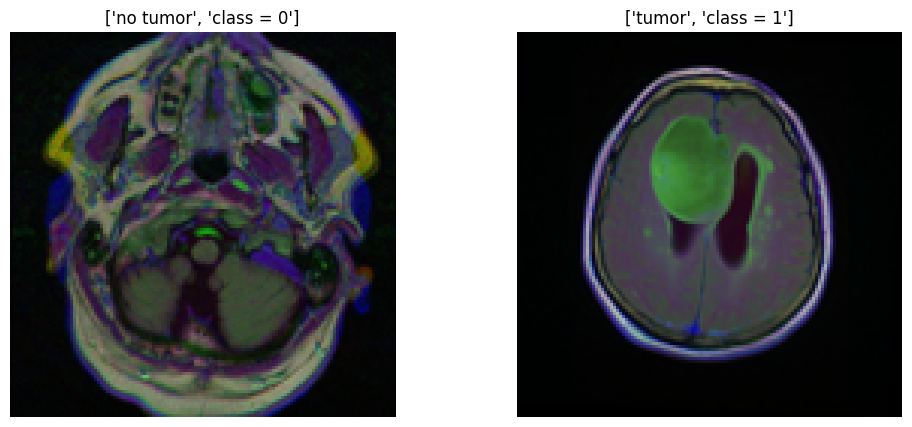

In [8]:
# Show one slice per class: no-tumor and tumor
fig = plt.figure(figsize=(12, 5))

for kclass in range(0, 2):
    ind = np.argwhere(y_train == kclass)
    ax  = fig.add_subplot(1, 2, kclass + 1)
    ax.imshow(x_train[ind[0][0]])
    ax.set_title([label_names[kclass], 'class = {}'.format(kclass)])
    ax.axis('off')

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

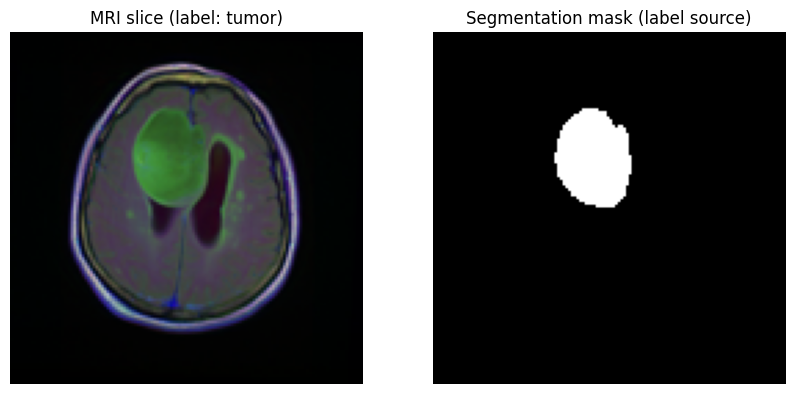

In [9]:
# Show an MRI slice alongside its tumor mask
# This illustrates how the classification label was derived
isel = np.argwhere(y_train == 1)[0][0]  # first tumor example

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(x_train[isel])
ax1.set_title('MRI slice (label: tumor)')
ax1.axis('off')

# Find the corresponding mask in mask_pngs using the index from original split
train_indices = list(train_test_split(range(len(x_data)), test_size=0.2, random_state=42)[0])
original_idx  = train_indices[isel]
msk = np.array(Image.open(mask_pngs[original_idx]).convert('L'))
ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(msk, cmap=plt.cm.gray)
ax2.set_title('Segmentation mask (label source)')
ax2.axis('off')

## 6. Build and train the CNN model

In [10]:
# CNN architecture
# with the Dense(128) hidden layer
# Input shape is (128, 128, 3) instead of (28, 28, 1) since brain MRI scans
# are larger and already 3-channel.

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(name='features'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Flatten)              │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
batch_size = 32
epochs     = 15

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.7238 - loss: 0.5407 - val_accuracy: 0.7841 - val_loss: 0.4332
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8069 - loss: 0.4052 - val_accuracy: 0.8159 - val_loss: 0.3791
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8338 - loss: 0.3240 - val_accuracy: 0.8698 - val_loss: 0.2999
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8632 - loss: 0.2751 - val_accuracy: 0.9079 - val_loss: 0.2520
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8989 - loss: 0.2256 - val_accuracy: 0.9016 - val_loss: 0.2434
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9279 - loss: 0.1780 - val_accuracy: 0.8984 - val_loss: 0.2383
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9378 - loss: 0.1453 - val_accuracy: 0.8635 - val_loss: 0.2854
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9335 - loss: 0.1577 - val_accuracy: 0.8984 - 

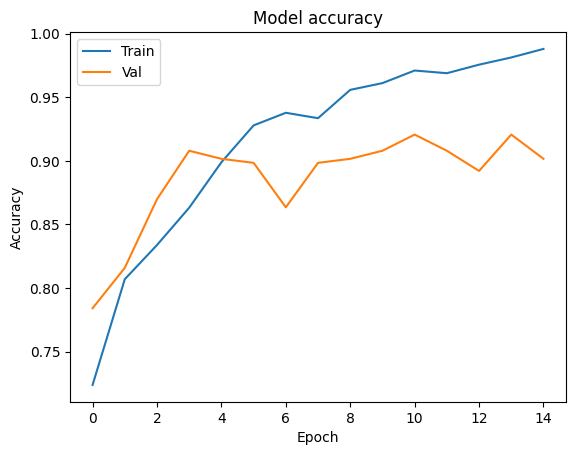

In [12]:
# Visualize the model accuracy over epochs
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

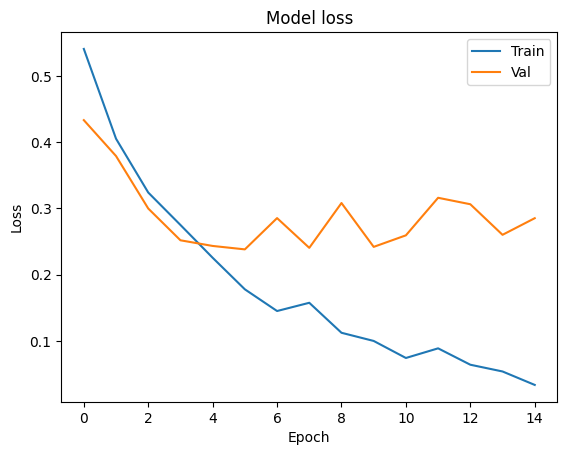

In [13]:
# Visualize the model loss over epochs
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

## 7. Evaluate the classifier on the test data

In [14]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

score = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

# Convert back from one-hot categorical encoding to integers
y_test_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_test_pred, target_names=label_names))
print(confusion_matrix(y_test, y_test_pred))

Test loss:     0.35036757588386536
Test accuracy: 0.9211195707321167
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

    no tumor       0.93      0.95      0.94       520
       tumor       0.90      0.87      0.88       266

    accuracy                           0.92       786
   macro avg       0.91      0.91      0.91       786
weighted avg       0.92      0.92      0.92       786

[[493  27]
 [ 35 231]]


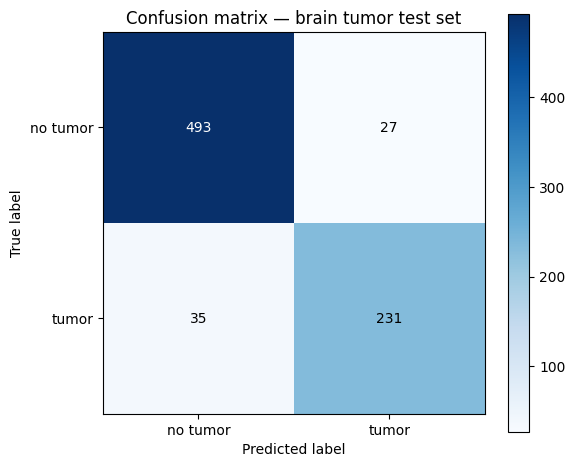

In [15]:
# Confusion matrix — visual representation
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(label_names)
ax.set_yticklabels(label_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2. else 'black')
ax.set_title('Confusion matrix — brain tumor test set')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

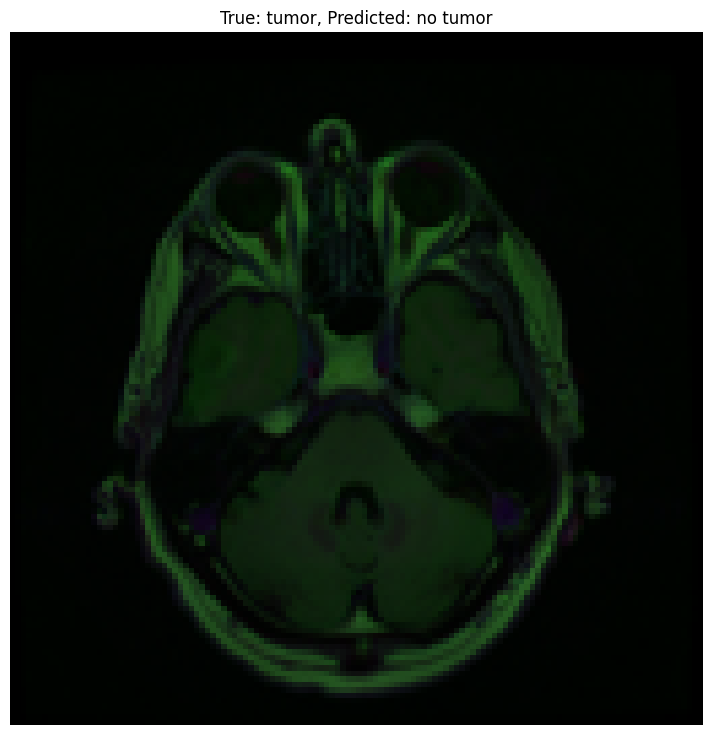

True label for image 31 is 1 (tumor)
Predicted label is 0 (no tumor)


In [16]:
# Inspect misclassifications: tumor slices predicted as no-tumor (false negatives)
# These are the most dangerous errors in a medical context.

isel = np.where((y_test == 1) & (y_test_pred == 0))[0]  # tumor predicted as no-tumor

if len(isel) > 0:
    idx = isel[0]
    plt.figure(figsize=(9, 9))
    plt.imshow(x_test[idx])
    plt.title('True: {}, Predicted: {}'.format(
        label_names[y_test[idx]], label_names[y_test_pred[idx]]))
    plt.axis('off')
    plt.show()
    print('True label for image {} is {} ({})'.format(idx, y_test[idx], label_names[y_test[idx]]))
    print('Predicted label is {} ({})'.format(y_test_pred[idx], label_names[y_test_pred[idx]]))
else:
    print('No misclassified samples found for the specified condition.')

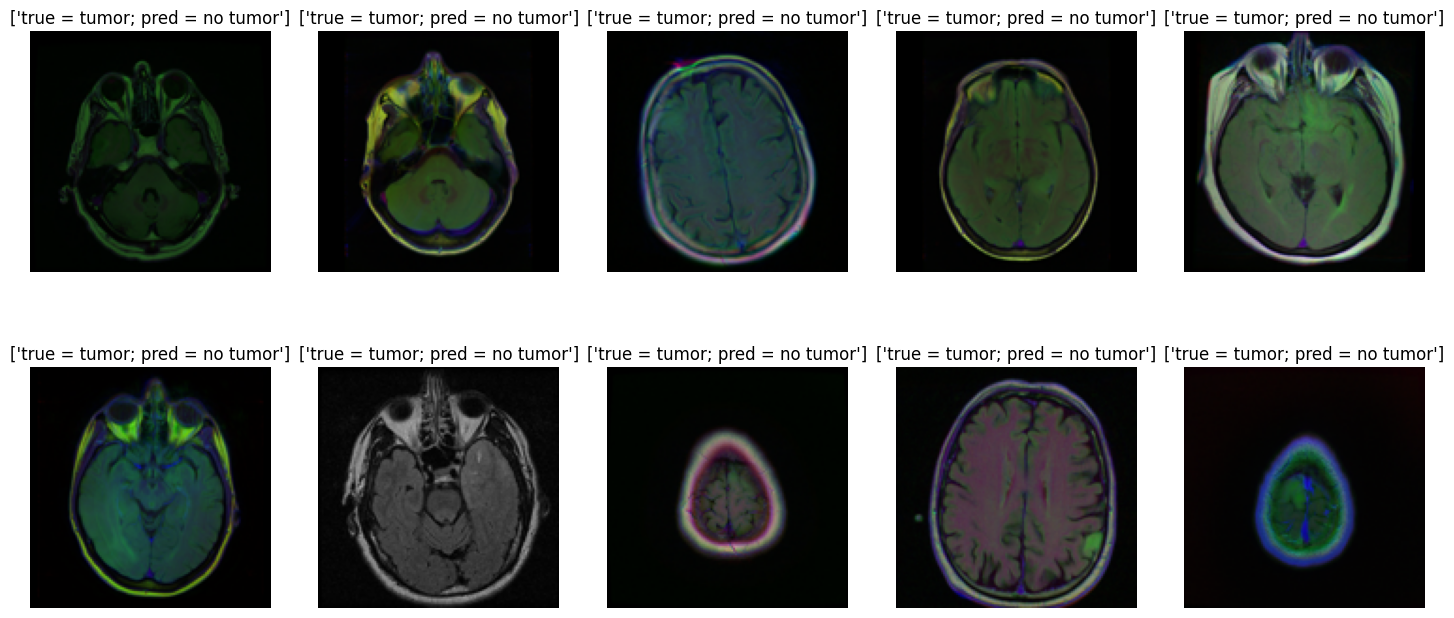

In [17]:
# Looking at tumor slices predicted as no-tumor (false negatives):
isel   = np.where((y_test == 1) & (y_test_pred == 0))
np.shape(isel)
isel   = np.squeeze(isel)
n_show = min(10, len(np.atleast_1d(isel)))

fig = plt.figure(figsize=(18, 8))
cnt = 0
for k in np.atleast_1d(isel)[:n_show]:
    cnt += 1
    ax = fig.add_subplot(2, 5, cnt)
    ax.imshow(x_test[k])
    ax.set_title(['true = {}; pred = {}'.format(
        label_names[y_test[k]], label_names[y_test_pred[k]])])
    ax.axis('off')

## 8. Prediction probabilities for a single test image

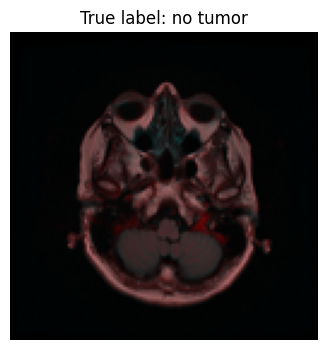

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
Most likely class:   no tumor -- Probability: 1.0
Second most likely:  tumor -- Probability: 6.9674577e-10


In [18]:
# Change isel to inspect a different test image
isel = 0

plt.figure(figsize=(4, 4))
plt.imshow(x_test[isel])
plt.title('True label: {}'.format(label_names[y_test[isel]]))
plt.axis('off')
plt.show()

probabilities = model.predict(np.array([x_test[isel]]))
index         = np.argsort(probabilities[0, :])

print('Most likely class:  ', label_names[index[1]], '-- Probability:', probabilities[0, index[1]])
print('Second most likely: ', label_names[index[0]], '-- Probability:', probabilities[0, index[0]])

## 9. Discussion

**Dataset.** The LGG Brain MRI Segmentation dataset contains 3929 MRI slices from 110 patients with lower-grade gliomas. Each slice has three MRI channels (pre-contrast, FLAIR, post-contrast) and a binary segmentation mask. Since no explicit classification labels are provided, we derive them from the masks: if any pixel in the mask is non-zero, the slice is labelled as containing a tumor. This gives a binary classification problem — tumor present vs absent.

**Class imbalance.** Most slices have no visible tumor (the tumor affects only part of the brain at any given cross-section). This imbalance makes classification harder: a model that always predicts 'no tumor' can achieve high accuracy but has no clinical value. The precision/recall per class in the classification report reveals whether the model handles this imbalance correctly.

**Model.** The CNN architecture is adapted for the 128×128×3 brain MRI input. The two convolutional blocks learn to detect local patterns (edges, textures, abnormal intensity regions), and the Dense layers classify the resulting features. The key difference from the class example is the input resolution: 128×128 instead of 28×28, which requires the convolutional blocks to process more spatial information.

**Clinical relevance.** False negatives (tumor predicted as no-tumor) are more dangerous than false positives in a medical screening context. This kind of error analysis is essential in medical AI and connects to the discussion of precision vs recall in the classification report.